# Overview

This notebook is authored by:

*Trevor Santy*

*Dmitrii Novikov*

## Goal

The goal of this project was to develop a custom Optical Character Recognition (OCR) system that will be capable of recognizing both typed and handwritten characters from images. Our OCR system was designed to classify individual letters and numbers and convert them into machine-readable text.

To better understand the effectiveness of different machine learning approaches for OCR, we implemented and compared two different classification methods:

1) a custom template-matching OCR system built manually from scratch, and
2) a machine learning pipeline using Principal Component Analysis (PCA) combined with K-Nearest Neighbors (KNN).

The project focused on both typed characters and handwritten characters, so that we could compare how different OCR methods perform on clean, consistent text versus more unpredictable handwriting. Typed characters are usually uniform and easier to recognize, while handwritten characters vary greatly from person to person, making them much more challenging for an OCR system to classify accurately.

A major objective of the project was to build much of the OCR pipeline manually rather than relying on prebuilt OCR libraries. We implemented: <strong> image preprocessing, grayscale conversion, thresholding, noise removal, connected component analysis, character segmentation, template matching, dimensionality reduction using PCA, and machine learning classification.</strong>

By manually implementing these components, we gained a deeper understanding of how OCR systems operate internally and how preprocessing decisions affect model performance.

Another goal of the project was to evaluate whether a manually implemented OCR model could perform competitively against against a standard machine learning baseline like KNN. In this scenario, the PCA + KNN pipeline served as the baseline model because KNN is a widely used instance-based machine learning algorithm that classifies samples based on similarity to nearby training examples in feature space.

The template-based OCR system was chosen as the candidate model. Unlike the PCA + KNN classifier, the template OCR system was manually designed to compare incoming character images directly against stored reference templates using pixel similarity measurements. The system also incorporated PCA dimensionality reduction to improve template comparison efficiency and reduce noise in handwritten character recognition.

We tested both models using the same preprocessing pipeline, so the comparison is fair. The goal was to see whether a manually implemented OCR system could remain competitive against a more advanced machine learning model that learns patterns from data.

## Data Description

Our project used two major datasets:

TMNIST (Typography MNIST) for typed characters
EMNIST Balanced for handwritten characters

These datasets allowed us to evaluate OCR performance on both typed computer-generated text and more difficult handwritten text.

<strong>TMNIST Dataset </strong> is a typography-based extension of the MNIST format. It contains over 281,000 grayscale images representing 94 different characters:

{'0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\', ']', '^', '_', '`', '{', '|', '}', '~'}

Each image is represented as a 28×28 grayscale image similar to the original MNIST dataset format. The images were generated using many different font styles. Features of the dataset consist of font names (e.g Salsa-Regular, MouseMemoirs-Regular), a labels column that represents the target character (the symbol being shown in each image), and the remaining 784 columns, where each feature corresponds to a single pixel value in a 28×28 grayscale image representation of the character. The label column contains the target character class for each image. In our machine learning models only the 784 pixel values will be used as input features, while the font name column is excluded as it represents metadata rather than predictive information.

<strong>EMNIST Dataset</strong> is an extension of the original MNIST handwritten digit dataset. It was created from the NIST Special Database 19 and converted into the same 28×28 image format as MNIST. In particular, we used the EMNIST Balanced split, which contains 131,600 handwritten character images, 47 balanced classes of handwritten digits and letters. This dataset is more difficult because different people write characters differently. The dataset consists of 784 input features representing pixel intensity values per sample, along with a target label indicating one of the 47 character classes.

## Methods

We decided to compare the performance of a manually implemented OCR system against an ML baseline using PCA and K-Nearest Neighbors (KNN) for typed and handwritten character recognition.

<strong> Manually implemented OCR Model: </strong>
* Custom template matching OCR system built manually from scratch
* Manual image preprocessing and character segmentation pipeline
* PCA-enhanced template matching for dimensionality reduction
* Weighted nearest-template voting system using top-k matches
* Connected component analysis for character extraction
* Foreground cropping and nearest-neighbor resizing for normalization

<strong>PCA + KNN Baseline Model:</strong>
* Principal Component Analysis (PCA) for dimensionality reduction
* K-Nearest Neighbors (KNN) classifier with k = 3
* Vectorized 32×32 image feature representations
* Shared preprocessing pipeline for fair model comparison
* Stratified train-test splitting

Before classification, all images were processed through a shared preprocessing pipeline to standardize input format and reduce noise. First, each image was converted to grayscale and binarized. Second, noise removal was applied. Third, Connected component analysis was implemented using a depth-first search approach to find individual character regions and filter out small noisy parts of the image. Lastly, extracted characters were then cropped to their foreground regions and resized to a fixed 32×32 representation. These steps ensured that both models received consistent and comparable inputs.

Both models were evaluated using identical preprocessing steps and dataset splits to ensure a fair comparison. In particular, PCA was used to make dimensional pixel data smaller. This helps make the system more robust against noise and handwriting. 

Manually implemented OCR was tested in raw pixel space and PCA-transformed feature space to evaluate whether dimensionality reduction improves template matching performance. The KNN model used PCA-transformed features as its input representation for classification.

For both models, the datasets were split using an 80/20 train-test split with stratified sampling to ensure that class distribution is balanced across training and testing sets. Manually implemented model and KNN + PCA pipeline were evaluated on both the TMNIST (typed) dataset and the EMNIST (handwritten) dataset. Performance was evaluated by using classification accuracy. The results were compared across both datasets to understand how each approach performs on clean typed characters vs more complex and robust handwritten characters.


## Responsibilities

***Dmitrii Novikov:***
Dmitrii is implemented the PCA + KNN baseline model used for comparison against the template OCR system. This included converting images into vectorized 32×32 representations and applying PCA for dimensionality reduction. In addition, he trained and tuned the KNN classifier with k = 3 using the processed feature space.

***Trevor Santy:***
Trevor was responsible for implementing the majority of the OCR system, including the full image preprocessing pipeline. This includes grayscale conversion, Otsu thresholding, noise removal, connected component analysis, and character segmentation using a depth-first search approach. He also implemented foreground cropping and resizing to standardize all inputs to 32×32 images. In addition, he built the manual OCR model with MSE similarity matching and a weighted top-k voting system. He also integrated PCA into the template OCR pipeline and handled dataset loading and train-test splitting for both TMNIST and EMNIST.

***Everyone:***
As a group, we wrote the final report together, basically each of us wrote 50% of the report.

# Importing/Cleaning Up Data

In [208]:
# Notebook configuration

# Typed TMNIST Alphabet CSV. Put this file in the same folder as the notebook, or change the path.
TYPED_DATA_PATH = "94_character_TMNIST.csv"

# Optional EMNIST CSV. Leave as None to try loading EMNIST Balanced from OpenML.
EMNIST_CSV_PATH = "emnist-balanced-FULL.csv"
# Keep samples limited so the notebook can run in a reasonable amount of time.
# Increase these if your computer can handle it.
MAX_TYPED_SAMPLES = 20000
MAX_EMNIST_SAMPLES = 20000

# Shared experiment settings
TEST_SIZE = 0.20
RANDOM_STATE = 42
PCA_COMPONENTS = 30
KNN_NEIGHBORS = 3
TEMPLATE_SIZE = (32, 32)

# Set to False only if you want to skip one dataset while debugging.
RUN_TYPED_EXPERIMENT = True
RUN_HANDWRITTEN_EXPERIMENT = True

We start by importing the necessary libraries for building and evaluating our OCR system. These libraries handle numerical operations, dataset processing, machine learning models, and image manipulation.

We use NumPy and Pandas for efficient array and dataset handling, and PIL for image loading and conversion.

In [209]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

For machine learning and evaluation, we use scikit-learn to perform dataset splitting, dimensionality reduction, classification, and performance evaluation.

In [210]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_openml

We also include standard Python utilities for file handling and dataset management

In [211]:
import os
import subprocess
import zipfile

In [212]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

The datasets used in this project contain labels stored in different naming formats. Some labels include prefixes such as "digit_", "lower_", or "upper_". It depends on the type of character represented in the dataset. Before training the OCR systems, we standardized these labels into a simplified and consistent representation.

The following function removes unnecessary prefixes and converts all labels into a cleaner format. This normalization step ensures that both OCR models operate on identical class labels and prevents inconsistencies during training and evaluation processes.

In [213]:
def clean_label(label: str) -> str:
    label = str(label)

    if label.startswith("digit_"):
        return label.replace("digit_", "")

    if label.startswith("lower_"):
        return label.replace("lower_", "")

    if label.startswith("upper_"):
        return label.replace("upper_", "")

    return label

# Image Preprocessing

Image preprocessing is an important part of the OCR pipeline because raw image data often contains unnecessary background information and noise that can negatively affect classification performance. Before classification can begin, we standardized all images into a consistent representation.

The preprocessing pipeline in this project consists of several parts. First, images are converted into grayscale representations to simplify the data and reduce computational complexity. Second, we applied Otsu thresholding to automatically determine an appropriate threshold value for separating foreground text from background pixels. Next, binary masks are created to isolate character regions. Lastly, characters are cropped to their foreground boundaries and resized into 32×32 format. Consequently, all samples have identical dimensions before classification.

Both OCR systems share these preprocessing steps to ensure fair comparison between the manually implemented model and the machine learning baseline (KNN + PCA).

# Grayscale Conversion

OCR systems achieve better results when processing images with a single grayscale intensity channel instead of a full-color RGB. Since character recognition is mostly about recognizing shapes and patterns rather than color, grayscale conversion reduces computational complexity without losing important information.

The function below utilizes the PIL (Python Imaging Library) to transform input images into grayscale NumPy arrays. By stripping away color, we created a solid baseline for more advanced preprocessing steps, like thresholding and binarization.

In [214]:
def to_grayscale_np(img: Image.Image) -> np.ndarray:
    return np.array(img.convert("L"), dtype=np.uint8)

## Otsu Thresholding

To separate text from its background, we have implemented Otsu’s Method. Instead of manually selecting a threshold value, Otsu thresholding automatically determines the optimal threshold based on the intensity distribution of the image.

Otsu thresholding works by maximizing the variance between foreground and background pixel groups. This allows the manually implemented OCR system to adapt to different image brightness levels. In addition, this is also improves robustness when processing large datasets containing images with varying contrast and lighting conditions.

In [215]:
def otsu_threshold(gray: np.ndarray) -> int:
    hist = np.bincount(gray.ravel(), minlength=256).astype(np.float64)

    total = gray.size
    sum_total = np.dot(np.arange(256), hist)

    sum_b = 0.0
    w_b = 0.0

    max_var = -1.0
    threshold = 127

    for t in range(256):

        w_b += hist[t]

        if w_b == 0:
            continue

        w_f = total - w_b

        if w_f == 0:
            break

        sum_b += t * hist[t]

        m_b = sum_b / w_b
        m_f = (sum_total - sum_b) / w_f

        between = w_b * w_f * (m_b - m_f) ** 2

        if between > max_var:
            max_var = between
            threshold = t

    return threshold

## Image Binarization

Our next step was to transform images into binary masks. In these masks, foreground pixels represent character regions while background pixels represent empty image space.

Binarization strips away visual noise and focuses strictly on the essential features by converting continuous grayscale intensity values into a clean foreground-background representation. This significantly improves later steps such as connected component analysis and template matching because the OCR systems only need to process meaningful information.

In [216]:
def binarize(
    gray: np.ndarray,
    invert: bool = False,
    threshold: Optional[int] = None
) -> np.ndarray:

    if threshold is None:
        threshold = otsu_threshold(gray)

    fg = gray <= threshold

    if invert:
        fg = ~fg

    return fg

## Foreground Cropping

Character images contain large amounts of empty background space surrounding the actual foreground character. The function below removes empty regions surrounding the character and crops the image tightly around the foreground pixels. A small amount of padding is preserved to avoid cutting off character boundaries.

In [217]:
def crop_to_foreground(
    mask: np.ndarray,
    pad: int = 1
) -> np.ndarray:

    ys, xs = np.where(mask)

    if len(xs) == 0:
        return mask.copy()

    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)

    y1 = min(mask.shape[0] - 1, y1 + pad)
    x1 = min(mask.shape[1] - 1, x1 + pad)

    return mask[y0:y1 + 1, x0:x1 + 1]

## Character Resizing and Normalization

Since character sizes vary across both typed and handwritten datasets, each extracted character must be resized into a fixed representation before classification. The function below performs nearest-neighbor resizing and converts all character masks into a standardized 32×32 representation. This process ensures that both OCR systems receive consistent input dimensions while preserving important character information.

In [218]:
def resize_mask_nn(
    mask: np.ndarray,
    size: Tuple[int, int]
) -> np.ndarray:

    h, w = mask.shape
    H, W = size

    if h == 0 or w == 0:
        return np.zeros((H, W), dtype=np.float32)

    ys = (np.arange(H) * (h / H)).astype(int)
    xs = (np.arange(W) * (w / W)).astype(int)

    ys = np.clip(ys, 0, h - 1)
    xs = np.clip(xs, 0, w - 1)

    out = mask[ys[:, None], xs[None, :]]

    return out.astype(np.float32)

## Connected Component Analysis

Connected component analysis is an important stage of the OCR pipeline because it allows the system to isolate individual character regions from a binary image. The algorithm scans through the image pixel by pixel and groups together neighboring foreground pixels into connected regions.

This process allows the system to separate multiple characters inside the same image and remove small noise that could negatively affect classification accuracy.

### Component Data Structure
Each connected component identified during image traversal is stored using a custom data structure.  The Component class inlcudes coordinates of all pixels that belong to the region, the bounding box, and the total area of the component measured in pixels. We will use information later for noise filtering, character extraction, and OCR prediction.

In [219]:
@dataclass
class Component:
    pixels: np.ndarray
    bbox: Tuple[int, int, int, int]
    area: int

### Connected Component Extraction

The following function manually implements connected component extraction using a DFS algorithm. During traversal, the algorithm records the coordinates of all pixels belonging to the component while simultaneously computing the component bounding box and total area.

In [220]:
def connected_components(mask: np.ndarray) -> List[Component]:

    H, W = mask.shape

    visited = np.zeros((H, W), dtype=bool)

    comps: List[Component] = []

    for y in range(H):

        for x in range(W):

            if not mask[y, x] or visited[y, x]:

                continue

            stack = [(y, x)]

            visited[y, x] = True

            pix = []

            y0 = y1 = y

            x0 = x1 = x

            while stack:

                cy, cx = stack.pop()

                pix.append((cy, cx))

                y0 = min(y0, cy)

                y1 = max(y1, cy)

                x0 = min(x0, cx)

                x1 = max(x1, cx)

                neighbors = [

                    (cy - 1, cx),

                    (cy + 1, cx),

                    (cy, cx - 1),

                    (cy, cx + 1),

                ]

                for ny, nx in neighbors:

                    if 0 <= ny < H and 0 <= nx < W:

                        if mask[ny, nx] and not visited[ny, nx]:

                            visited[ny, nx] = True

                            stack.append((ny, nx))

            pixels = np.array(pix, dtype=np.int32)

            comps.append(

                Component(

                    pixels=pixels,

                    bbox=(y0, x0, y1, x1),

                    area=len(pix),

                )

            )

    return comps

### Noise Removal

Real-world images often have noisy areas caused resulting from thresholding artifacts, stray pixels, or general image defects. These areas are not meaningful characters and can negatively affect OCR accuracy if they are preserved. The function below removes connected components whose area falls below a minimum threshold value.

In [221]:
def remove_small_specks(
    mask: np.ndarray,
    min_area: int = 10
) -> np.ndarray:

    comps = connected_components(mask)

    keep = np.zeros_like(mask, dtype=bool)

    for comp in comps:

        if comp.area >= min_area:

            keep[comp.pixels[:, 0], comp.pixels[:, 1]] = True

    return keep

# Manually Implemented OCR Model

The OCR model implemented in this project is a manually implemented OCR model. This system performs recognition by comparing unknown character masks against stored template representations.It combines traditional image processing methods with dimensionality reduction techniques. Character templates are normalized, resized, and transformed using Principal Component Analysis (PCA). During prediction, the system compares unknown characters against stored templates using Mean Squared Error (MSE) similarity measurements.

The model does not rely on a single nearest template but on weighted voting system is used across the top-k nearest template matches.

## TemplateOCR Class Initialization

The manually implmented OCR class stores template representations and handles all template matching operations. During initialization, the template size is defined so that all characters are normalized into a consistent representation before similarity comparison.

### add_template():

The method below adds new templates into the OCR system. Before templates are stored, they are normalized through foreground cropping and nearest-neighbor resizing. Hence, all templates would share identical dimensions.

### fit_pca():

Principal Component Analysis (PCA) is used to reduce the dimensionality of template representations before similarity matching. High-dimensional pixel representations can have noise that drops classification performance.

PCA allows our OCR system to focus on the most important features in characters. The method below converts all templates into vector representations, trains a PCA model, and stores the transformed feature vectors for later similarity matching.

### match_glyph():

The method below performs OCR prediction by comparing an unknown character against stored template representations. The character is first normalized. Similarity is measured using Mean Squared Error (MSE), where smaller distances indicate greater similarity between character structures.

As was mentioned before, instead of relying on a single nearest neighbor, our model uses weighted top-k voting across the closest matches. Each candidate contributes to the final prediction according to its similarity score.

### mse():

Here, MSE is used as the similarity metric for template comparison. The metric measures the average squared pixel difference between two template representations. Smaller MSE shows higher similarity between characters. On the other hand, higher MSE shows lower similarity between characters.


In [222]:
class TemplateOCR:

    def __init__(self, template_size: Tuple[int, int] = (32, 32)):

        self.template_size = template_size

        self.templates: Dict[str, List[np.ndarray]] = {}

        self.pca = None

        self.pca_templates: Dict[str, List[np.ndarray]] = {}

 

    def add_template(self, label: str, mask: np.ndarray) -> None:

        label = clean_label(label)

 

        mask = mask.astype(bool)

        mask = crop_to_foreground(mask, pad=1)

        tmpl = resize_mask_nn(mask, self.template_size)

 

        self.templates.setdefault(label, []).append(tmpl)

 

    def fit_pca(self, n_components: int = 30) -> None:

        all_vectors = []

        all_labels = []

 

        for label, tmpl_list in self.templates.items():

            for tmpl in tmpl_list:

                all_vectors.append(tmpl.flatten())

                all_labels.append(label)

 

        all_vectors = np.array(all_vectors, dtype=np.float32)

 

        self.pca = PCA(n_components=n_components, random_state=42)

        transformed = self.pca.fit_transform(all_vectors)

 

        self.pca_templates = {}

 

        for label, vec in zip(all_labels, transformed):

            self.pca_templates.setdefault(label, []).append(vec)

 

    def match_glyph(self, glyph_mask: np.ndarray) -> str:

        glyph_mask = crop_to_foreground(glyph_mask, pad=1)

        glyph = resize_mask_nn(glyph_mask, self.template_size)

 

        scores = []

 

        if self.pca is not None:

            glyph_vec = glyph.flatten().reshape(1, -1)

            glyph_vec = self.pca.transform(glyph_vec)[0]

 

            for label, vec_list in self.pca_templates.items():

                for vec in vec_list:

                    score = self.mse(glyph_vec, vec)

                    scores.append((score, label))

        else:

            for label, tmpl_list in self.templates.items():

                for tmpl in tmpl_list:

                    score = self.mse(glyph, tmpl)

                    scores.append((score, label))

 

        scores.sort(key=lambda x: x[0])

 

        k = 6

        top_scores = scores[:k]

 

        votes = {}

 

        for score, label in top_scores:

            if label not in votes:

                votes[label] = 0.0

 

            votes[label] += 1.0 / (score + 1e-6)

 

        best_label = max(votes, key=votes.get)

 

        return best_label

 

    @staticmethod

    def mse(a: np.ndarray, b: np.ndarray) -> float:

        d = a - b

        return float(np.mean(d * d))

## Alphanumeric Label Filtering

The TMNIST dataset have multiple types of symbols and character labels. However,our project focuses on alphanumeric OCR classification involving only digits and alphabetic characters. The function below checks whether a label represents a single valid number or alphabetic character. Labels that do not satisfy this requirement are removed from the dataset during preprocessing. This function will ensure that the models will not learn from unnecessary symbol classes.

In [223]:
def is_number_or_letter(label: str) -> bool:

    label = str(label)

    if len(label) != 1:

        return False

    return label.isdigit() or label.isalpha()

## Automatic TMNIST Dataset Detection

Our OCR system can automatically locate the TMNIST dataset CSV file inside the working directory. This function scans all CSV files and attempts to identify the correct dataset by examining the label structure.

In [224]:
def find_tmnist_alphabet_csv() -> Optional[str]:

    for fname in os.listdir("."):

        if not fname.lower().endswith(".csv"):

            continue

        try:

            df_check = pd.read_csv(
                fname,
                usecols=["labels"]
            )

        except Exception:

            continue

        labels = df_check["labels"].astype(str)

        unique_labels = set(labels)

        has_letters = any(
            label.isalpha()
            for label in unique_labels
        )

        has_digits = any(
            label.isdigit()
            for label in unique_labels
        )

        if has_letters and has_digits and len(unique_labels) > 10:

            return fname

    return None

## Automatic TMNIST Download

Our OCR system can automatically download the TMNIST dataset if it is not already available locally. The function below first checks whether a compatible CSV file already exists. If it cannot be found, the system downloads the dataset directly from Kaggle.

In [225]:
def download_tmnist_alphabet_if_missing() -> str:

    csv_path = find_tmnist_alphabet_csv()

 

    if csv_path is not None:

        return csv_path

 

    print("TMNIST Alphabet CSV not found.")

    print("Trying to download TMNIST Alphabet from Kaggle...")

 

    dataset_name = "nikbearbrown/tmnist-alphabet-94-characters"

    zip_path = "tmnist-alphabet-94-characters.zip"

 

    subprocess.run(

        [

            "kaggle",

            "datasets",

            "download",

            "-d",

            dataset_name,

            "-p",

            "."

        ],

        check=True

    )

 

    if os.path.exists(zip_path):

        with zipfile.ZipFile(zip_path, "r") as zip_ref:

            zip_ref.extractall(".")

 

    csv_path = find_tmnist_alphabet_csv()

 

    if csv_path is None:

        raise FileNotFoundError(

            "Could not find TMNIST Alphabet CSV after download. "

            "Make sure Kaggle downloaded nikbearbrown/tmnist-alphabet-94-characters."

        )

 

    return csv_path


## TMNIST Typed Character Dataset Loading

The function below loads and preprocesses the TMNIST typed character dataset. Several preprocessing methods are performed during loading. First, the dataset is read into memory using Pandas. Second, labels are normalized and filtered. Third, each flattened row is reshaped into a 28×28 image representation. Binary masks are then generated and cropped to the foreground character region.

In addition, we limited the dataset size to 20,000 samples to reduce computational cost.

In [226]:
def load_typed_dataset(

    root: str,

    invert: bool = False,

    min_area: int = 10

) -> Tuple[List[np.ndarray], List[str]]:

    csv_path = root

    if not os.path.exists(csv_path):

        csv_path = download_tmnist_alphabet_if_missing()

    print(f"Loading typed TMNIST CSV from: {csv_path}")

    df = pd.read_csv(csv_path)

    # keep TMNIST from being enormous

    df = df[:20000]

    if "labels" not in df.columns:

        raise ValueError("TMNIST CSV must have a 'labels' column.")

    labels = df["labels"].astype(str).tolist()

    drop_cols = []

    for col in ["names", "labels"]:

        if col in df.columns:

            drop_cols.append(col)

    X = df.drop(columns=drop_cols).values

    masks = []

    fixed_labels = []

    for row, label in zip(X, labels):

        label = clean_label(label)

        if not is_number_or_letter(label):

            continue

        img = row.reshape(28, 28).astype(np.uint8)

        mask = img > 30

        mask = crop_to_foreground(mask, pad=1)

        if mask.any():

            masks.append(mask)

            fixed_labels.append(label)

    print()

    print("Typed TMNIST number/letter labels loaded:")

    print(sorted(set(fixed_labels)))

    print(

        f"Number of typed TMNIST number/letter classes: "

        f"{len(set(fixed_labels))}"

    )

    return masks, fixed_labels

## EMNIST Dataset Loading

In addition to TMNIST, we also evaluate OCR performance on handwritten characters using the EMNIST dataset. Handwritten OCR is significantly more difficult than typed OCR because handwritten characters because they have writing style differences and other complexities such as inconsistent stroke thickness and etc.

We used two options to load the EMNIST data. First, to load the dataset directly from OpenML. Second, download as local CSV file.

We chose balanced dataset in order to eliminate class bias and ensure that the model does not favor more frequent letters. It have 47 distinct classes.

### EMNIST OPENML LOADER

After loading, the dataset is limited to a maximum number of samples to reduce computational complexity. Each flattened image vector is reshaped into a 28×28 grayscale image and converted into a binary mask.

In [227]:
def load_emnist_openml(
    max_samples: int = 20000
) -> Tuple[List[np.ndarray], List[str]]:

    """
    Loads EMNIST from OpenML.

    If one name fails, the code tries the next possible OpenML name.

    This is here because OpenML names can be picky.
    """

    possible_names = [

        "EMNIST_Balanced",

        "EMNIST-Balanced",

        "EMNIST Balanced",

        "emnist-balanced",

    ]

    last_error = None

    for dataset_name in possible_names:

        try:

            print(
                f"Trying to load EMNIST using OpenML name: {dataset_name}"
            )

            data = fetch_openml(
                dataset_name,
                version="active",
                as_frame=False
            )

            X = data.data

            y = data.target.astype(str)

            break

        except Exception as e:

            last_error = e

    else:

        raise RuntimeError(

            "Could not load EMNIST from OpenML. "

            "Download EMNIST Balanced CSV from Kaggle/NIST instead, "

            "or try changing the dataset name in possible_names."

        ) from last_error

    if max_samples is not None:

        X = X[:max_samples]

        y = y[:max_samples]

    masks = []

    for row in X:

        img = row.reshape(28, 28).astype(np.uint8)

        # EMNIST/MNIST-style images usually have bright ink on dark background.

        mask = img > 30

        # EMNIST is sometimes rotated/flipped depending on source.

        # For classification accuracy, this is usually okay as long as all images match.

        mask = crop_to_foreground(mask, pad=1)

        masks.append(mask)

    labels = list(y)

    return masks, labels

### EMNIST CSV Loader

We applied several operations during loading. First, flattened image vectors are reshaped into 28×28 images (we applied also some orientation corrections because some EMNIST CSV formats store handwritten characters in rotated or flipped form). Second, after orientation correction, binary masks are generated and cropped to the foreground region. This will ensure that handwritten samples remain visually aligned before classification.

In [228]:
def load_emnist_from_csv(

    csv_path: str,

    max_samples: Optional[int] = 20000

) -> Tuple[List[np.ndarray], List[str]]:

    """

    Loads EMNIST from a CSV file.

 

    Expected format:

    label,pixel1,pixel2,...,pixel784

 

    This works with Kaggle-style EMNIST CSV files.

    """

 

    print(f"Loading EMNIST CSV from: {csv_path}")

 

    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)

 

    if max_samples is not None:

        data = data[:max_samples]

 

    y = data[:, 0].astype(int).astype(str)

    X = data[:, 1:]

 

    masks = []

 

    for row in X:

        img = row.reshape(28, 28).astype(np.uint8)

 

        # Some EMNIST CSV versions are rotated.

        # This fixes visual orientation for many CSV versions.

        img = np.rot90(img, k=-1)

        img = np.fliplr(img)

 

        mask = img > 30

        mask = crop_to_foreground(mask, pad=1)

        masks.append(mask)

 

    return masks, list(y)

## Mask-to-Feature Vector Transformation

The function below converts a list of binary characters into a fixed-sized feature vector. Each mask is resized to a consistent shape (32x32). This ensures that all samples have the same dimensions. After resizing, each image is flattened into a 1D vector. We need this because ML models like PCA and KNN cannot directly process 2D image and require inputs in a consistent numerical vector.

In [229]:
def masks_to_vectors(

    masks: List[np.ndarray],

    size: Tuple[int, int] = (32, 32)

) -> np.ndarray:

    vectors = []

 

    for mask in masks:

        resized = resize_mask_nn(mask.astype(bool), size)

        vectors.append(resized.flatten())

 

    return np.array(vectors, dtype=np.float32)

# Dataset visualization

This function displays sample character images together with their labels. It shows a 10x10 grid of dataset images.

In [230]:
def show_sample_images(
    masks: List[np.ndarray],
    labels: List[str],
    title: str,
    samples: int = 100
):

    if not masks:
        print("No images to show:", title)
        return

    plt.figure(figsize=(20, 20))

    for i, img in enumerate(masks[:samples]):

        plt.subplot(10, 10, i + 1)
        plt.xticks([]); plt.yticks([])

        img = np.zeros((32, 32)) if img is None or img.size == 0 else img

        plt.imshow(img, cmap="gray")

        if labels:
            plt.title(str(labels[i]), fontsize=8)

    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

The function below runs visualization for TMNIST and EMNIST. It displays typed characters from TMNIST and handwritten characters in EMNIST

In [231]:
def visualize_datasets():

    if RUN_TYPED_EXPERIMENT:
        show_sample_images(typed_masks, typed_labels, "TMNIST Typed")

    if RUN_HANDWRITTEN_EXPERIMENT:
        show_sample_images(emnist_masks, emnist_labels, "EMNIST Handwritten")

The funciton below runs both datasets and dislays sample images from both of them.

Loading typed TMNIST CSV from: 94_character_TMNIST.csv

Typed TMNIST number/letter labels loaded:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of typed TMNIST number/letter classes: 62
Loading EMNIST CSV from: emnist-balanced-FULL.csv


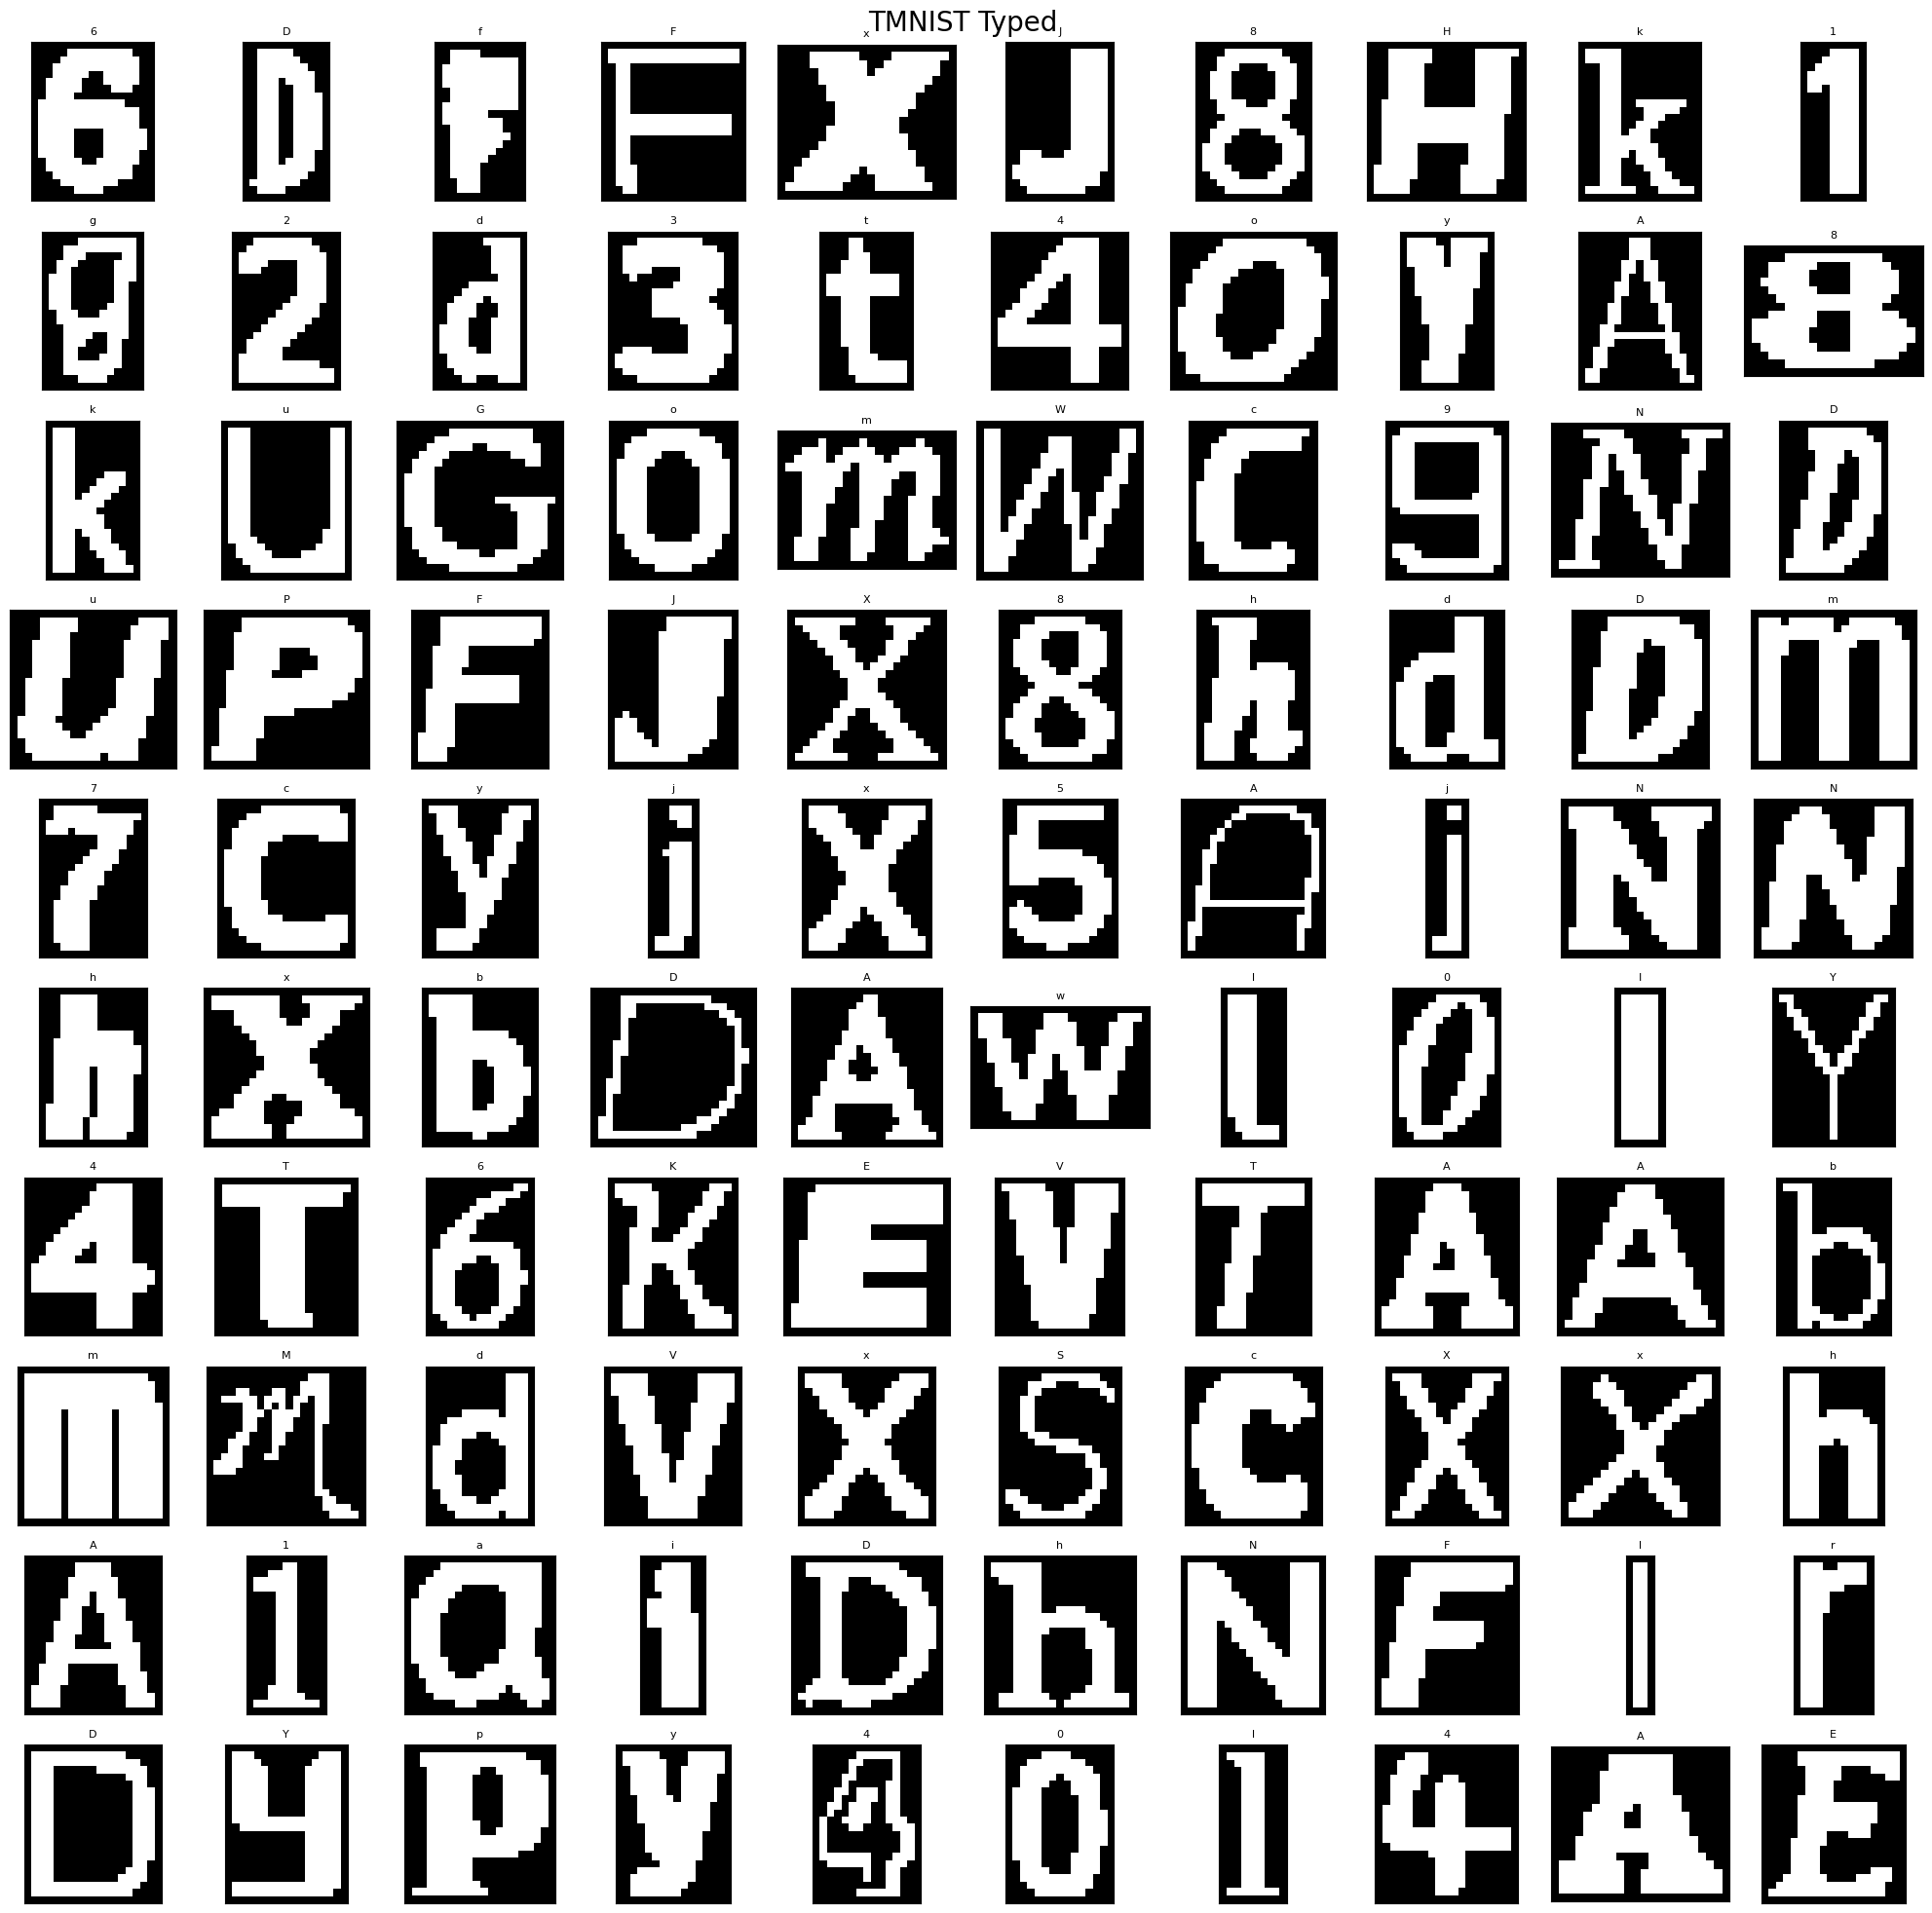

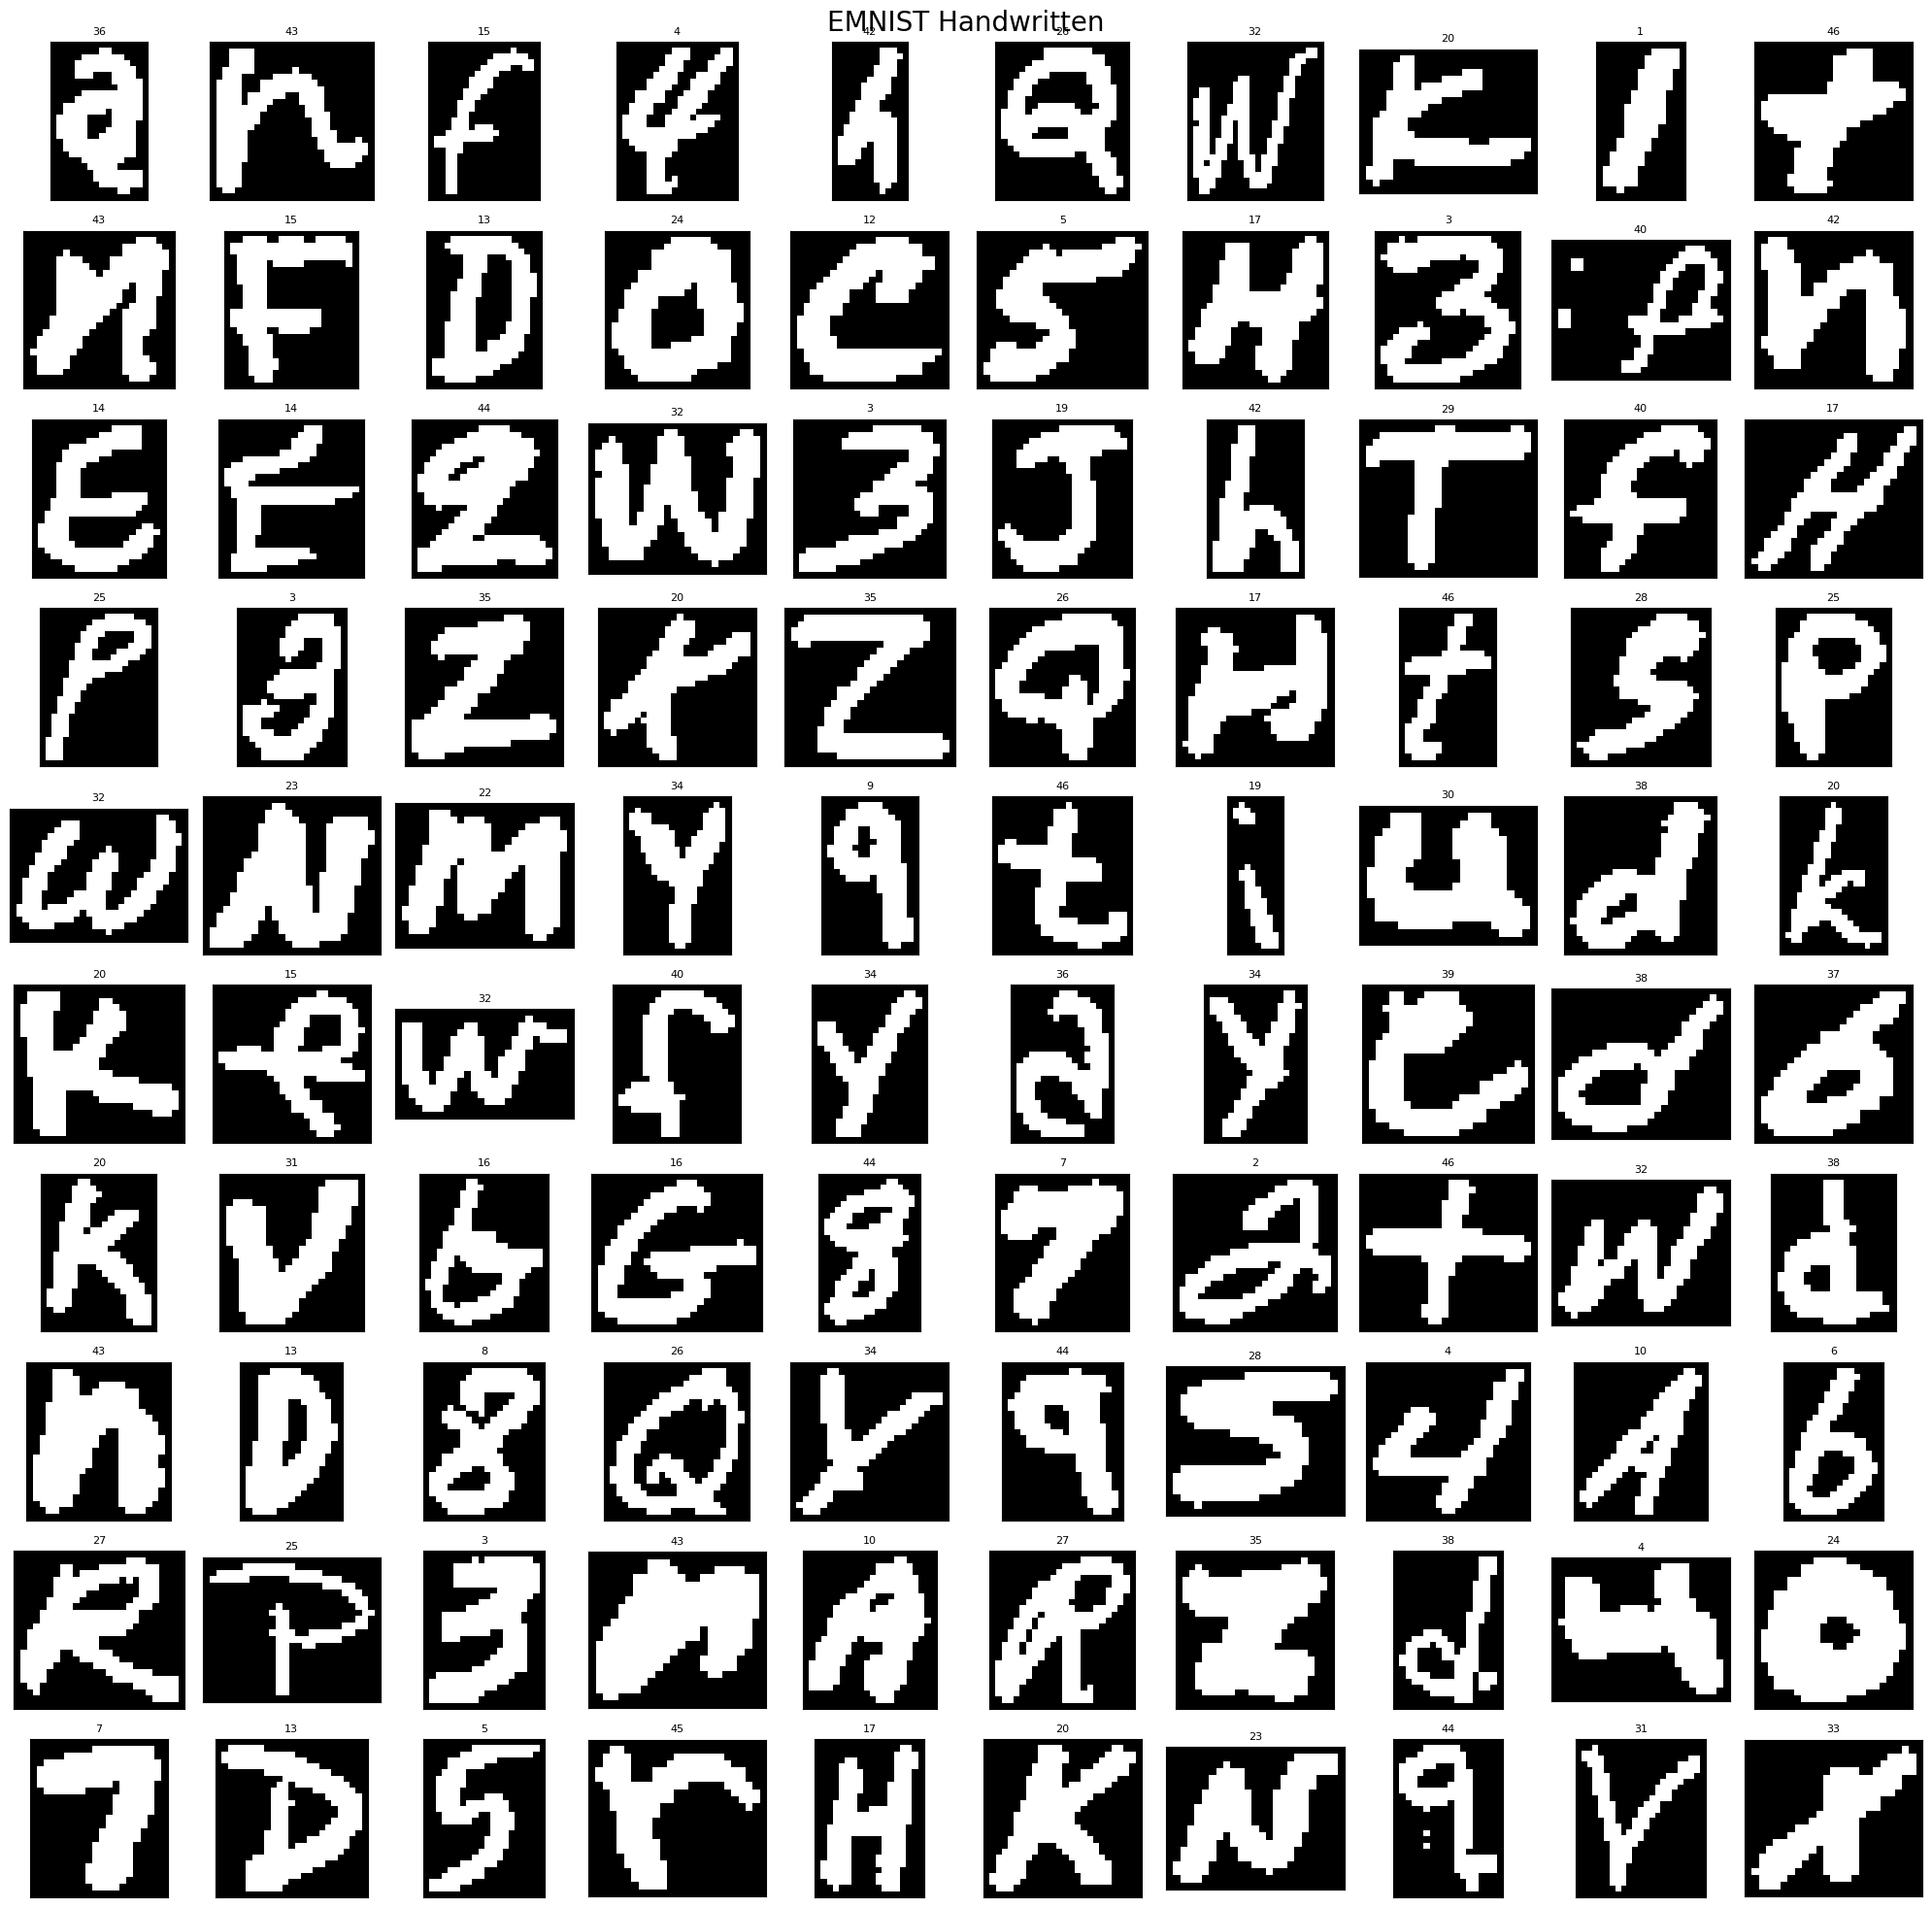

In [232]:
typed_masks, typed_labels = load_typed_dataset(
    TYPED_DATA_PATH
)

if RUN_HANDWRITTEN_EXPERIMENT:

    try:

        if EMNIST_CSV_PATH and os.path.exists(EMNIST_CSV_PATH):

            emnist_masks, emnist_labels = load_emnist_from_csv(
                EMNIST_CSV_PATH,
                max_samples=MAX_EMNIST_SAMPLES
            )

        else:

            emnist_masks, emnist_labels = load_emnist_openml(
                max_samples=MAX_EMNIST_SAMPLES
            )

    except Exception:

        emnist_masks, emnist_labels = load_emnist_openml(
            max_samples=MAX_EMNIST_SAMPLES
        )

visualize_datasets()

The TMNIST dataset have clean and consistent typed characters. They are generated from computer fonts. Most acharacters are centered and have little noise. This makes easier for our OCR model to classify the images.

On the other hand, EMNIST dataset have handwritten characters. They vary highly in shape and thickness. In addition, some of the samples are inconsistent which makes image classification more difficult.

# Class Distribution Visualization

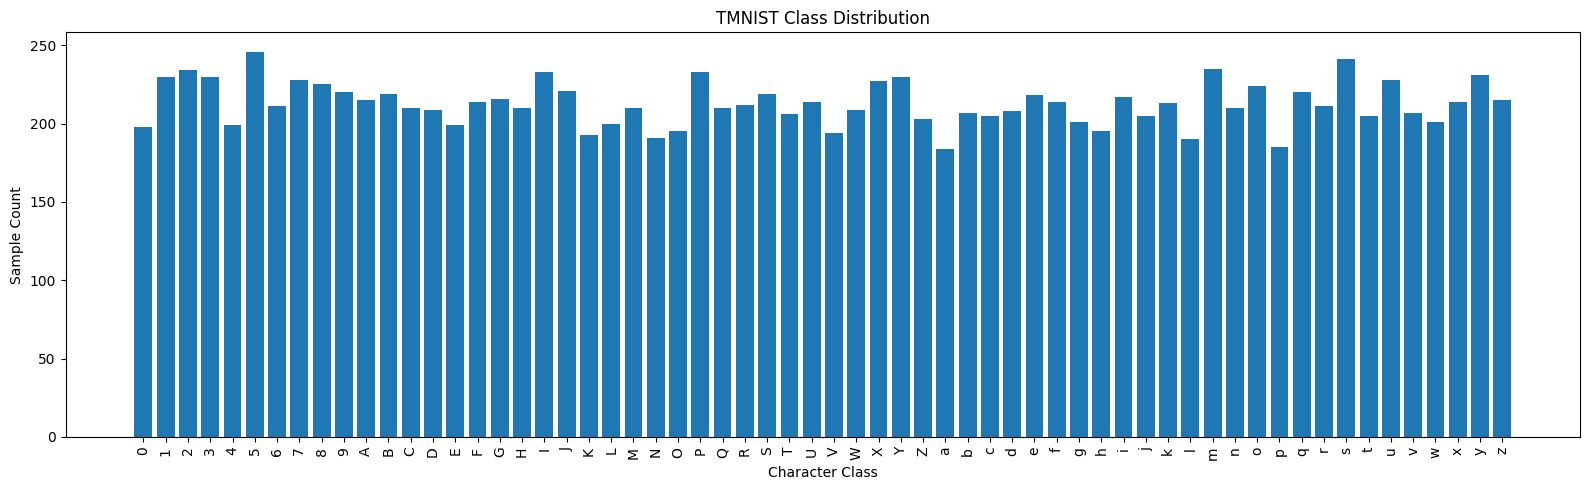

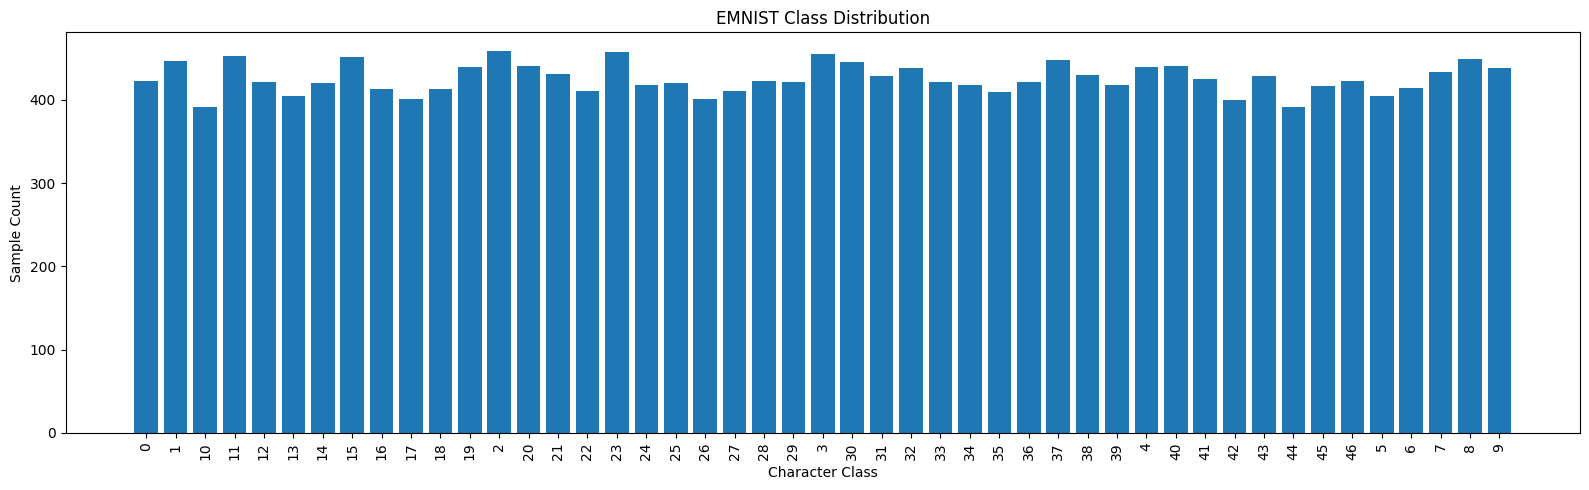

In [233]:
def plot_class_distribution(labels, title):

    values, counts = np.unique(labels, return_counts=True)

    plt.figure(figsize=(16, 5))

    plt.bar(values.astype(str), counts)

    plt.xticks(rotation=90)

    plt.title(title)

    plt.xlabel("Character Class")

    plt.ylabel("Sample Count")

    plt.tight_layout()

    plt.show()

plot_class_distribution(
    typed_labels,
    "TMNIST Class Distribution"
)

plot_class_distribution(
    emnist_labels,
    "EMNIST Class Distribution"
)

The class distribution plots how samples are spread across different character classes in both TMNIST and EMNIST datasets.

For TMNIST, the labels have easy readable structure, containing digits(0-9) and letters (A-Z, a-z). Because of this, this dataset easy to interpret. The ditribution is relatively balanced with each class have similar sample counts (approximately 180-250 samples per class).

For EMNIST, the labels are less intuitive. They are represented as numeric indices (0,1,10,11,12, etc..). This can be explained by the fact that EMNIST uses encoded class mappings rather than human-readable lables (mapping table is attached below). Each cllass of the EMNIST dataset have approximately 360-400 samples. This showes that EMNIST is slightly more uniformly distributed than TMNIST. Overall, both datasets are balanced.

Here is the mapping table for the EMNIST dataset:

| Index | ASCII | Character |
|------:|------:|:----------|
| 0 | 48 | 0 |
| 1 | 49 | 1 |
| 2 | 50 | 2 |
| 3 | 51 | 3 |
| 4 | 52 | 4 |
| 5 | 53 | 5 |
| 6 | 54 | 6 |
| 7 | 55 | 7 |
| 8 | 56 | 8 |
| 9 | 57 | 9 |
| 10 | 65 | A |
| 11 | 66 | B |
| 12 | 67 | C |
| 13 | 68 | D |
| 14 | 69 | E |
| 15 | 70 | F |
| 16 | 71 | G |
| 17 | 72 | H |
| 18 | 73 | I |
| 19 | 74 | J |
| 20 | 75 | K |
| 21 | 76 | L |
| 22 | 77 | M |
| 23 | 78 | N |
| 24 | 79 | O |
| 25 | 80 | P |
| 26 | 81 | Q |
| 27 | 82 | R |
| 28 | 83 | S |
| 29 | 84 | T |
| 30 | 85 | U |
| 31 | 86 | V |
| 32 | 87 | W |
| 33 | 88 | X |
| 34 | 89 | Y |
| 35 | 90 | Z |
| 36 | 97 | a |
| 37 | 98 | b |
| 38 | 100 | d |
| 39 | 101 | e |
| 40 | 102 | f |
| 41 | 103 | g |
| 42 | 104 | h |
| 43 | 110 | n |
| 44 | 113 | q |
| 45 | 114 | r |
| 46 | 116 | t |

# Dataset Split

Next, we have to ensure that both datasets are prepared for training and evaluation. Hence, we splitted them into training and testing subsets. We preserved the class distribution in both splits to avoid biias.

In [234]:
def split_dataset_notebook(masks, labels, test_size=TEST_SIZE):
    clean_labels = [clean_label(label) for label in labels]
    return train_test_split(
        masks,
        clean_labels,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=clean_labels
    )

# Training The Model

The function below trains our manually implemented OCR model by storing each training sample as a template. It iterates through the training dataset where each mask is paired with its corresponding label. For every (label-mask) pair, we store character representation using add_template method. By doing this, we create a "library" of known character patters. Our model can later use this for classification. This approach is effective for the controlled datasets (datasets where the samples are clean and follow the same structure).

In [235]:
def train_ocr_model(

    ocr: TemplateOCR,

    X_train: List[np.ndarray],

    y_train: List[str]

) -> None:

    for mask, label in zip(X_train, y_train):

        ocr.add_template(label, mask)

# Evaluating Our Model

The function below evaluates how well our model performs on the unseen (test) data. It iterates through each test image and compares the model's prediction with the actual class label. match_glyph function allows the OCR to predict a character. A counter increased if the prediction is correct. This function returns the overall accuracy as the (correct_predictions/total_number_of_test_samples).

In [236]:
def evaluate_ocr_model(

    ocr: TemplateOCR,

    X_test: List[np.ndarray],

    y_test: List[str]

) -> float:

    correct = 0

 

    for mask, label in zip(X_test, y_test):

        predicted = ocr.match_glyph(mask)

        actual = clean_label(label)

 

        if predicted == actual:

            correct += 1

 

    return correct / len(y_test)

# Run Manually Implemented Model (Candidate Model)

The function below runs a full manually implemented OCR model which uses template-based approach. It prints basic dataset information (number of samples, available classes, number of unique labels). Then, it splits dataset into training and testing sets via stratified split. It helps to preserve class distribution. Our model is initialized and trained by storing character templates from the training dataset. After training process, we apply PCA to reduce the dimensionality by removing less informative features to improve model's efficiency. The function an accuracy report of our candidate model.

In [237]:
def run_template_experiment_notebook(name, masks, labels):
    print(f"===== {name} TEMPLATE OCR =====")
    print(f"Total samples: {len(labels)}")
    print(f"Number of classes: {len(set(map(clean_label, labels)))}")

    X_train, X_test, y_train, y_test = split_dataset_notebook(masks, labels)

    ocr = TemplateOCR(template_size=TEMPLATE_SIZE)

    print("Training template OCR model...")
    train_ocr_model(ocr, X_train, y_train)

    print("Fitting PCA for template OCR model...")
    ocr.fit_pca(n_components=PCA_COMPONENTS)

    print("Evaluating template OCR model...")
    y_pred = [ocr.match_glyph(mask) for mask in X_test]
    accuracy = accuracy_score(y_test, y_pred)

    print(f"{name} template OCR accuracy: {accuracy * 100:.2f}%")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "dataset": name,
        "model_name": "Template OCR + PCA",
        "model": ocr,
        "accuracy": accuracy,
        "y_test": y_test,
        "y_pred": y_pred,
    }

# Run Baseline Model (KNN + PCA)

We chose KNN as a baseline model. We believe that it is a solid choice becase it is simple and straightforward. Instead trying to learn fixed parameters during training, it stores the examples and makes predictions by comparing an input to the most similar strored samples. Furthermore, KNN is extremely useful for OCR because it gives us an initial sense of wether our feature representation is informative (whether different character classes form distinguishable patterns in space) enough to distiguish between images of the characers.

The function below implements KNN + PCA pipeline. First, it cleans the labels and converts each of the images into a flattened numberical vector via mask_to_vectors function. Then, the dataset is split into training and testing sets via stratified split. It ensures fair evaluation because some characters can appear more frequently than others. Next, we built a pipeline that includes PCA and KNN classification. PCA helps to reduce the dimensionality but keeps informative features. This approach helps to improve both speed and the accuracy. Finally, the model is trained, makes predictions on the test set, and the accuracy/classification report is printed for performace evaluation.

In [238]:
def run_pca_knn_experiment_notebook(name, masks, labels):
    print(f"===== {name} PCA + KNN BASELINE =====")
    print(f"Using PCA components/features: {PCA_COMPONENTS}")
    print(f"Using KNN neighbors: {KNN_NEIGHBORS}")

    clean_labels = [clean_label(label) for label in labels]
    X = masks_to_vectors(masks, size=TEMPLATE_SIZE)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        clean_labels,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=clean_labels
    )

    model = Pipeline([
        ("pca", PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)),
        ("knn", KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS))
    ])

    print("Training PCA + KNN baseline...")
    model.fit(X_train, y_train)

    print("Evaluating PCA + KNN baseline...")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"{name} PCA + KNN accuracy: {accuracy * 100:.2f}%")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "dataset": name,
        "model_name": "PCA + KNN Baseline",
        "model": model,
        "accuracy": accuracy,
        "y_test": y_test,
        "y_pred": y_pred,
    }

# Confusion Matrix

The function below visualizes the model's performance using a confusion matrix. It shows the frequency of a character being correctly or incorrectly classified. In particular, it compares true labels vs. predicted labels. A confusion matrix helps us to identify which characters are frequently confused.

In [239]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(result, max_classes=20):
    labels = sorted(set(result["y_test"]) | set(result["y_pred"]))

    # Large 47+ class confusion matrices can become unreadable, so limit display if needed.
    if len(labels) > max_classes:
        labels = labels[:max_classes]
        print(f"Showing first {max_classes} classes only to keep the plot readable.")

    cm = confusion_matrix(result["y_test"], result["y_pred"], labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, xticks_rotation=90, values_format="d")
    plt.title(f"{result['dataset']} - {result['model_name']} Confusion Matrix")
    plt.show()

# Results Table

The function below combines all experiment outputs into a single well-structured table. It standardizes the output into a Pandas DataFrame. Moreover, it makes comparison across datasets (MNIST and EMNIST) and models (candidate vs baseline).

In [240]:
def make_results_table(results):
    rows = []
    for r in results:
        rows.append({
            "Dataset": r["dataset"],
            "Model": r["model_name"],
            "Accuracy": r["accuracy"],
            "Accuracy (%)": round(r["accuracy"] * 100, 2)
        })
    return pd.DataFrame(rows)

# Accuracy Comparison Plot

The function below generates a bar chart that compares model performance across datasets. In particular, it visualizes the differences between Template OCR + PCA and PCA + KNN. Thanks to it, we can easily interpret which model generalizes better and which dataset is harder.

In [241]:
def plot_accuracy_comparison(results_df):
    ax = results_df.plot(kind="bar", x="Dataset", y="Accuracy (%)", legend=False, figsize=(9, 5))
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("OCR Model vs PCA + KNN Baseline")
    ax.set_ylim(0, 100)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Data Preparation for typed characters

Here we load the dataset if enabled, limit dataset size for efficienct, and print dataset statistics.

In [242]:
typed_masks = None
typed_labels = None

if RUN_TYPED_EXPERIMENT:
    typed_masks, typed_labels = load_typed_dataset(TYPED_DATA_PATH)
    
    if MAX_TYPED_SAMPLES is not None and len(typed_labels) > MAX_TYPED_SAMPLES:
        typed_masks = typed_masks[:MAX_TYPED_SAMPLES]
        typed_labels = typed_labels[:MAX_TYPED_SAMPLES]
    
    print(f"Typed samples used: {len(typed_labels)}")
    print(f"Typed classes: {len(set(typed_labels))}")
    print(sorted(set(typed_labels)))
else:
    print("Typed experiment skipped.")

Loading typed TMNIST CSV from: 94_character_TMNIST.csv

Typed TMNIST number/letter labels loaded:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of typed TMNIST number/letter classes: 62
Typed samples used: 13197
Typed classes: 62
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


# Running experiments on OCR and KNN Baseline

## Running Typed Experiments

In [243]:
results = []

typed_ocr_result = None
typed_knn_result = None

if RUN_TYPED_EXPERIMENT:
    typed_ocr_result = run_template_experiment_notebook("Typed", typed_masks, typed_labels)
    results.append(typed_ocr_result)
else:
    print("Typed OCR experiment skipped.")
    
if RUN_TYPED_EXPERIMENT:
    typed_knn_result = run_pca_knn_experiment_notebook("Typed", typed_masks, typed_labels)
    results.append(typed_knn_result)
else:
    print("Typed KNN experiment skipped.")

===== Typed TEMPLATE OCR =====
Total samples: 13197
Number of classes: 62
Training template OCR model...
Fitting PCA for template OCR model...
Evaluating template OCR model...
Typed template OCR accuracy: 79.47%
              precision    recall  f1-score   support

           0       0.49      0.46      0.47        39
           1       0.78      0.85      0.81        46
           2       0.98      0.96      0.97        47
           3       0.95      0.91      0.93        46
           4       0.88      0.95      0.92        40
           5       0.94      0.90      0.92        49
           6       0.89      0.79      0.84        42
           7       0.96      0.98      0.97        46
           8       0.75      0.98      0.85        45
           9       0.90      0.82      0.86        44
           A       0.93      0.98      0.95        43
           B       0.78      0.91      0.84        44
           C       0.69      0.69      0.69        42
           D       0.97      0.

## EMNIST Dataset Loading

This block handles EMNIST dataset loading.

In [244]:
emnist_masks = None
emnist_labels = None

if RUN_HANDWRITTEN_EXPERIMENT:
    if EMNIST_CSV_PATH is not None:
        emnist_masks, emnist_labels = load_emnist_from_csv(
            EMNIST_CSV_PATH,
            max_samples=MAX_EMNIST_SAMPLES
        )
    else:
        emnist_masks, emnist_labels = load_emnist_openml(
            max_samples=MAX_EMNIST_SAMPLES
        )
    
    print(f"EMNIST samples used: {len(emnist_labels)}")
    print(f"EMNIST classes: {len(set(emnist_labels))}")
    print(sorted(set(emnist_labels)))
else:
    print("Handwritten experiment skipped.")

Loading EMNIST CSV from: emnist-balanced-FULL.csv
EMNIST samples used: 20000
EMNIST classes: 47
[np.str_('0'), np.str_('1'), np.str_('10'), np.str_('11'), np.str_('12'), np.str_('13'), np.str_('14'), np.str_('15'), np.str_('16'), np.str_('17'), np.str_('18'), np.str_('19'), np.str_('2'), np.str_('20'), np.str_('21'), np.str_('22'), np.str_('23'), np.str_('24'), np.str_('25'), np.str_('26'), np.str_('27'), np.str_('28'), np.str_('29'), np.str_('3'), np.str_('30'), np.str_('31'), np.str_('32'), np.str_('33'), np.str_('34'), np.str_('35'), np.str_('36'), np.str_('37'), np.str_('38'), np.str_('39'), np.str_('4'), np.str_('40'), np.str_('41'), np.str_('42'), np.str_('43'), np.str_('44'), np.str_('45'), np.str_('46'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9')]


## Running HandWritten Experiments

In [245]:
handwritten_ocr_result = None
handwritten_knn_result = None

if RUN_HANDWRITTEN_EXPERIMENT:
    handwritten_ocr_result = run_template_experiment_notebook("EMNIST Handwritten", emnist_masks, emnist_labels)
    results.append(handwritten_ocr_result)
else:
    print("Handwritten OCR experiment skipped.")
    
if RUN_HANDWRITTEN_EXPERIMENT:
    handwritten_knn_result = run_pca_knn_experiment_notebook("EMNIST Handwritten", emnist_masks, emnist_labels)
    results.append(handwritten_knn_result)
else:
    print("Handwritten KNN experiment skipped.")

===== EMNIST Handwritten TEMPLATE OCR =====
Total samples: 20000
Number of classes: 47
Training template OCR model...
Fitting PCA for template OCR model...
Evaluating template OCR model...
EMNIST Handwritten template OCR accuracy: 77.00%
              precision    recall  f1-score   support

           0       0.51      0.58      0.54        85
           1       0.48      0.70      0.57        89
          10       0.78      0.85      0.81        78
          11       0.74      0.76      0.75        90
          12       0.89      0.89      0.89        84
          13       0.83      0.85      0.84        81
          14       0.93      0.82      0.87        84
          15       0.65      0.54      0.59        90
          16       0.89      0.77      0.82        82
          17       0.81      0.81      0.81        80
          18       0.48      0.51      0.50        82
          19       0.88      0.77      0.82        88
           2       0.84      0.74      0.79        92
     

# Final Evaluation & Visualization

The final function below produces all report figures and summaries. It converts results into a table format, generates accuracy comparison plot, and displays confusion matrices for the models.

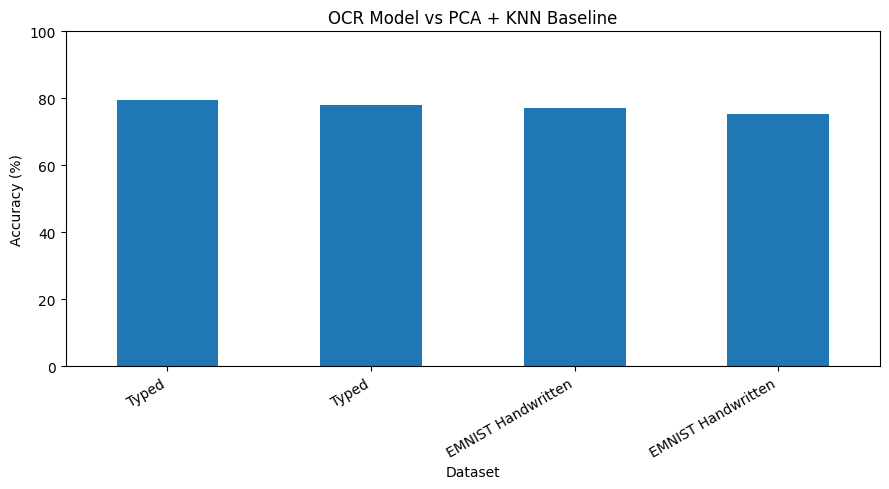

Showing first 20 classes only to keep the plot readable.


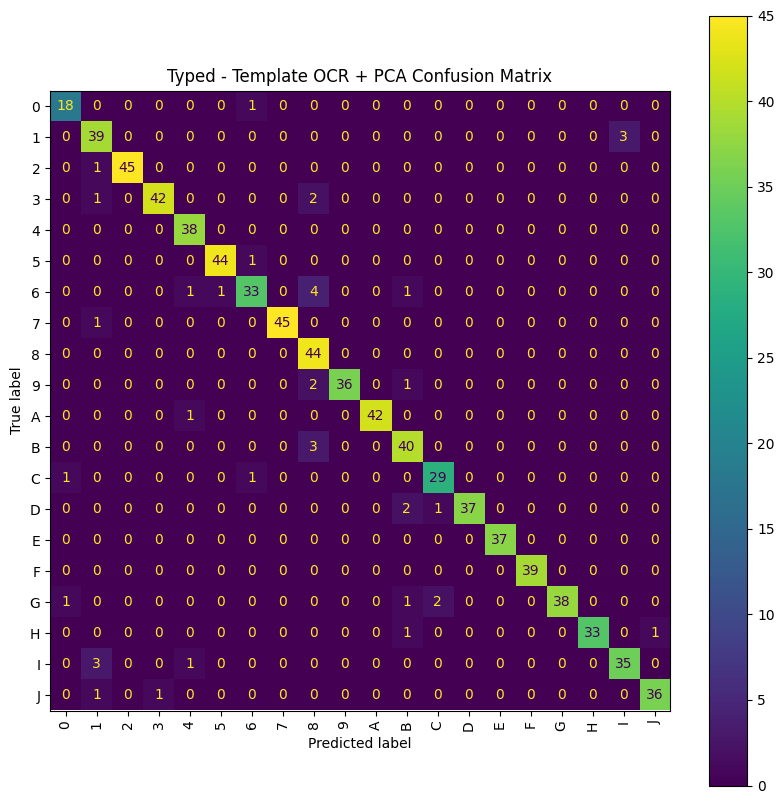

Showing first 20 classes only to keep the plot readable.


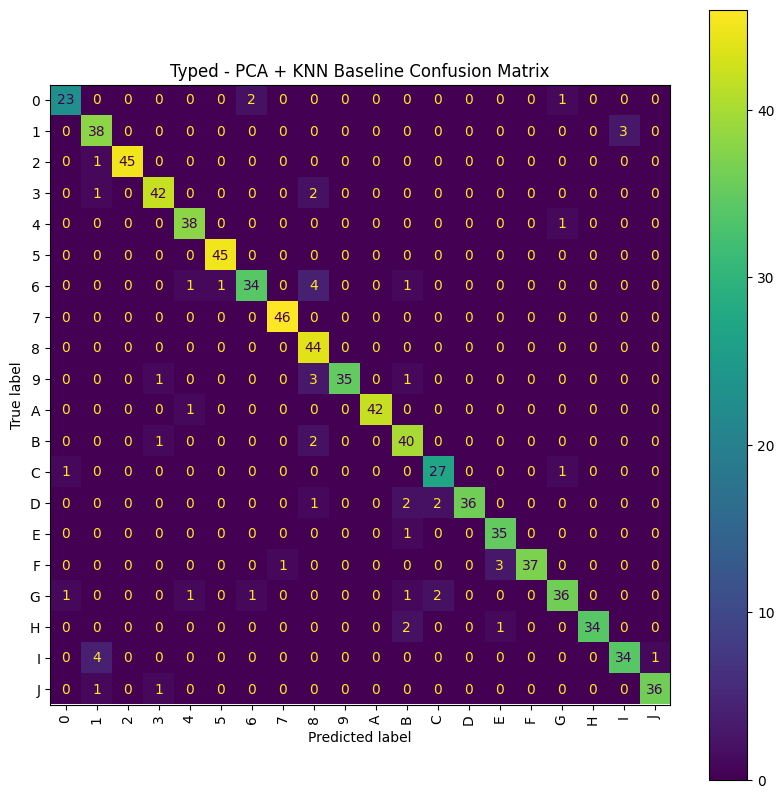

Showing first 20 classes only to keep the plot readable.


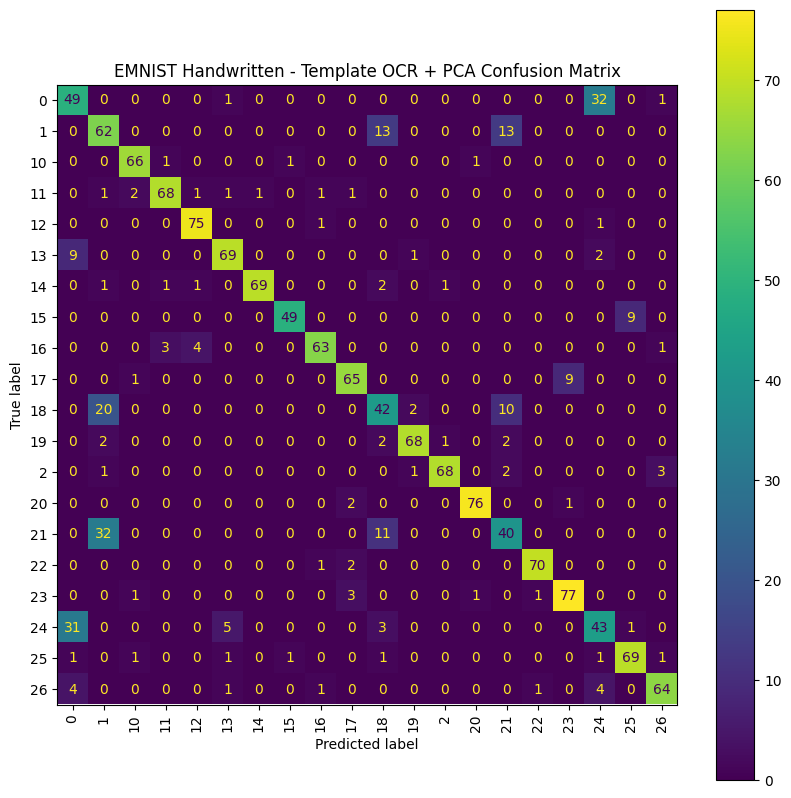

Showing first 20 classes only to keep the plot readable.


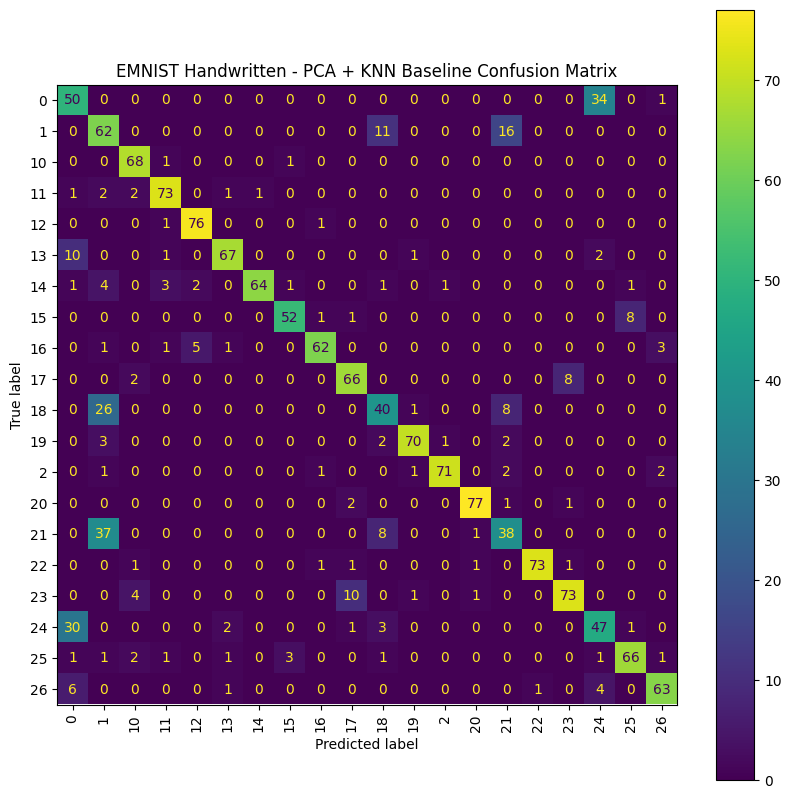

In [246]:
results_df = make_results_table(results)
results_df

plot_accuracy_comparison(results_df)

if typed_ocr_result is not None:
    plot_confusion_matrix(typed_ocr_result)
    
if typed_knn_result is not None:
    plot_confusion_matrix(typed_knn_result)
    
if handwritten_ocr_result is not None:
    plot_confusion_matrix(handwritten_ocr_result)
    
if handwritten_knn_result is not None:
    plot_confusion_matrix(handwritten_knn_result)

# Results/Interpretation